In [ ]:
#URL : https://www.kaggle.com/competitions/street-view-getting-started-with-julia/data

In [2]:
import kagglehub
kagglehub.login()
path = kagglehub.competition_download('street-view-getting-started-with-julia')

100%|██████████| 140M/140M [00:10<00:00, 13.7MB/s] 

Extracting files...


In [3]:
print(path)

/root/.cache/kagglehub/competitions/street-view-getting-started-with-julia


In [6]:
import numpy as np
import pandas as pd
import os
import zipfile
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import glob

print(tf.__version__)

PATH = '/root/.cache/kagglehub/competitions/street-view-getting-started-with-julia/'
IMAGE_SIZE = 40
BATCH_SIZE = 32

2.19.0


In [4]:
with zipfile.ZipFile(PATH + 'train.zip','r') as zip_ref:
    zip_ref.extractall(PATH)
with zipfile.ZipFile(PATH + 'test.zip','r') as zip_ref:
    zip_ref.extractall(PATH)

In [5]:
def preprocess_image(image):
    image = tf.image.decode_image(image,channels = 3,expand_animations=False)
    
    image.set_shape([None, None, 3])
    image = tf.image.resize(image,[IMAGE_SIZE,IMAGE_SIZE])
    image = tf.cast(image,tf.float32)
    image = image / 255.0
    return image
def load_row_img_label(image_path,label):
    image = tf.io.read_file(image_path)
    image = preprocess_image(image)
    return image,label
def get_train_valid_dataset():
    labels = pd.read_csv(PATH + 'trainLabels.csv')
    labels['Class'], uniques = labels['Class'].factorize()
    image_path = glob.glob(PATH + 'train/*.Bmp')

    dataset = pd.DataFrame({'image_path' : image_path})
    dataset['ID'] = dataset['image_path'].apply(
        lambda i : int(os.path.splitext(os.path.basename(i))[0]))
    dataset = dataset.merge(labels,on = 'ID')

    train_dataset,valid_dataset = train_test_split(dataset,test_size = 0.25,
                                                   shuffle = True,random_state = 42)
    
    train_dataset = tf.data.Dataset.from_tensor_slices((train_dataset['image_path'].to_numpy(),
                                                train_dataset['Class'].to_numpy()))
    train_dataset = train_dataset.map(load_row_img_label,num_parallel_calls = tf.data.AUTOTUNE)
    train_dataset = train_dataset.repeat().shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    
    
    valid_dataset = tf.data.Dataset.from_tensor_slices((valid_dataset['image_path'].to_numpy(),
                                                valid_dataset['Class'].to_numpy()))
    valid_dataset = valid_dataset.map(load_row_img_label,num_parallel_calls = tf.data.AUTOTUNE)
    valid_dataset = valid_dataset.repeat().shuffle(2048).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return uniques,train_dataset,valid_dataset
    
def load_row_image(image_path):
    image = tf.io.read_file(image_path)
    image = preprocess_image(image)
    return image
def get_test_dataset():
    image_path = glob.glob(PATH + 'test/*.Bmp')

    dataset = tf.data.Dataset.from_tensor_slices((image_path))
    dataset = dataset.map(load_row_image,num_parallel_calls = tf.data.AUTOTUNE)
    return dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [7]:
uniques,train_dataset,valid_dataset = get_train_valid_dataset()
test = get_test_dataset()

In [8]:
for image, label in train_dataset.shuffle(9999).take(1):
    plt.imshow(image[0].numpy())
    plt.title(f"Label: {label[0].numpy()}")
    plt.axis("off")

: 

: 

In [10]:
model = keras.Sequential([
    layers.Input(shape = (IMAGE_SIZE,IMAGE_SIZE,3)),

    layers.RandomRotation(0.25),
    layers.RandomTranslation(0.25,0.25),

    layers.Conv2D(filters = 64,kernel_size = 6,strides = 1,padding ='same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),
    
    layers.Conv2D(filters = 128,kernel_size = 3,strides = 1,padding ='same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),

    layers.Conv2D(filters = 256,kernel_size = 3,strides = 1,padding ='same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),

    layers.Conv2D(filters = 256,kernel_size = 3,strides = 1,padding ='same',activation = 'relu'),
    layers.MaxPool2D(pool_size = 3,strides = 2,padding = 'same'),

    layers.Flatten(),
    layers.BatchNormalization(),
    layers.Dropout(0.36),
    layers.Dense(units = 2048,activation = 'relu'),
    
    layers.BatchNormalization(),
    layers.Dropout(0.36),
    layers.Dense(units = 1024,activation = 'relu'),

    layers.BatchNormalization(),
    layers.Dropout(0.36),
    layers.Dense(units = 128,activation = 'relu'),
    
    layers.BatchNormalization(),
    layers.Dropout(0.36),
    layers.Dense(units = 62,activation = 'softmax')
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation_1               │ (None, 40, 40, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 40, 40, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 40, 40, 64)     │         6,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 5, 5, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 2304)           │         9,216 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2048)           │     4,720,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             

 Total params: 7,946,110 (30.31 MB)

 Trainable params: 7,935,102 (30.27 MB)

 Non-trainable params: 11,008 (43.00 KB)

In [12]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-4),
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)
history = model.fit(
    train_dataset,
    validation_data = valid_dataset,
    epochs = 250,
    steps_per_epoch = 512,
    validation_steps = 125,
    callbacks = [EarlyStopping(
        monitor = 'val_loss', 
        patience = 200, 
        restore_best_weights = True)]
)

Epoch 1/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 26s 32ms/step - accuracy: 0.0217 - loss: 4.7841 - val_accuracy: 0.0302 - val_loss: 4.1107
Epoch 2/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.0353 - loss: 4.4400 - val_accuracy: 0.0680 - val_loss: 4.0483
Epoch 3/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.0474 - loss: 4.2614 - val_accuracy: 0.0653 - val_loss: 4.0916
Epoch 4/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.0676 - loss: 4.1018 - val_accuracy: 0.0840 - val_loss: 4.0123
Epoch 5/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.0995 - loss: 3.8927 - val_accuracy: 0.1435 - val_loss: 3.5480
Epoch 6/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.1207 - loss: 3.7393 - val_accuracy: 0.1750 - val_loss: 3.3720
Epoch 7/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.1447 - loss: 3.5740 - val_accuracy: 0.2037 - val_loss: 3.3012
Epoch 8/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 15s 29ms/step - accuracy: 0.1610 - loss: 3

In [ ]:
history.history.keys()

<Axes: >

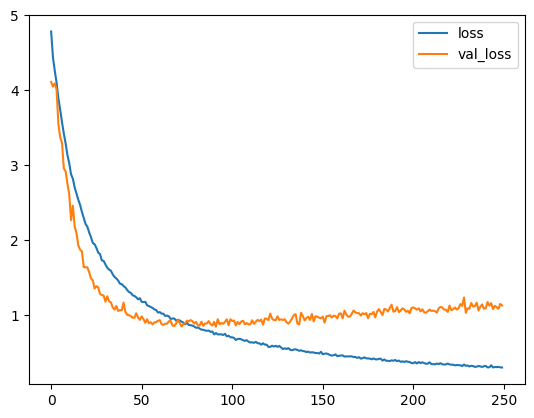

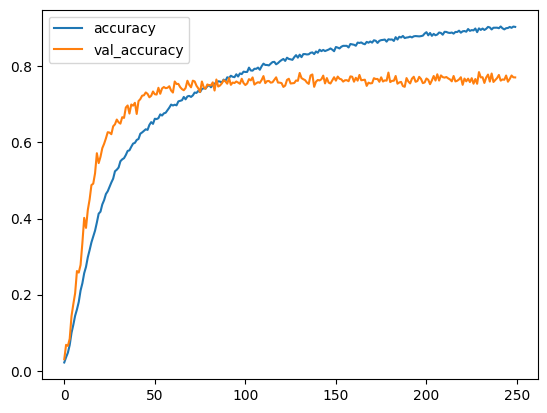

In [13]:
history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['accuracy', 'val_accuracy']].plot()

In [14]:
preds = model.predict(test).argmax(axis = 1)
preds = uniques[preds]
submission = pd.DataFrame({
    'ID' : [id for id in range(6284,12504)],
    'Class' : preds
})
submission.to_csv('submission.csv',index = False)

195/195 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
